# 23. Chap2-2 Confounding Audit

이 노트북은 22번에서 만든 데이터셋이 Chapter 2 보정 보고서의 요구사항을 만족하는지 검사합니다.

반드시 통과해야 하는 항목:

- image/mask/sample id 중복 없음
- train/eval 파일 overlap 없음
- `eval_matched`가 모든 color x shape x defect cell을 같은 개수로 포함
- `eval_stress`도 동일한 factor coverage를 가짐
- 모든 mask가 유효 class id와 target defect pixel을 포함

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "ch2_2_utils.py").exists():
    matches = (
        list(Path.cwd().glob("Deeplearning/*/2-2장/ch2_2_utils.py"))
        + list(Path.cwd().glob("Deeplearning/*/2*/chap2_2/ch2_2_utils.py"))
        + list(Path.cwd().glob("**/ch2_2_utils.py"))
    )
    if matches:
        NOTEBOOK_DIR = matches[0].parent
    else:
        NOTEBOOK_DIR = Path("Deeplearning") / "Vision 응용" / "2-2장"
sys.path.insert(0, str(NOTEBOOK_DIR))

from ch2_2_utils import *

paths = find_ch2_2_paths()
set_korean_font()
set_seed(7)
paths

Chapter22Paths(chap2_2_dir=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-2장'), chapter2_dir=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-1장'), chapter1_dir=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/1장'), data_root=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-2장/data/synthetic_metal_matched'), runs_root=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-2장/runs'), manifest_root=WindowsPath('C:/Users/준승/Desktop/2026-1/Study/Deeplearning/Vision 응용/2-2장/runs/manifests'))

In [2]:
if not (paths.data_root / "metadata" / "samples.csv").exists():
    generate_matched_factorial_dataset(paths.data_root)
samples = load_ch2_2_samples(paths.data_root)
audit = audit_ch2_2_dataset(samples, paths.runs_root / "audit")
audit

{'n_samples': 736,
 'unique_sample_id': 736,
 'unique_image_path': 736,
 'unique_mask_path': 736,
 'missing_image_files': 0,
 'missing_mask_files': 0,
 'coverage_pass': True,
 'train_eval_image_overlap': 0,
 'invalid_mask_value_samples': 0,
 'no_target_samples': 0,
 'mask_pass': True,
 'overall_pass': True}

## 23-1. Coverage Summary

In [3]:
coverage = pd.read_csv(paths.runs_root / "audit" / "coverage_summary.csv")
display(coverage)

if not audit["overall_pass"]:
    raise AssertionError(f"Chap2-2 audit failed: {audit}")
print("PASS: matched factorial dataset satisfies the correction requirements.")

,split,required_cells,observed_cells,min_count,max_count,balanced_full_factorial
0,train_matched,24,24,12,12,True
1,train_target_pool,2,2,24,24,True
2,eval_matched,40,40,6,6,True
3,eval_stress,40,40,4,4,True


PASS: matched factorial dataset satisfies the correction requirements.


## 23-2. Factor별 cell count 시각화

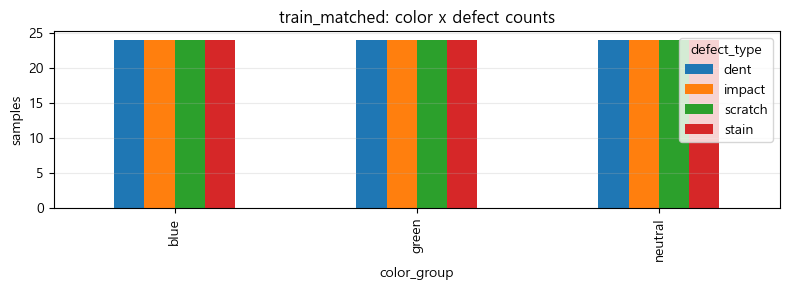

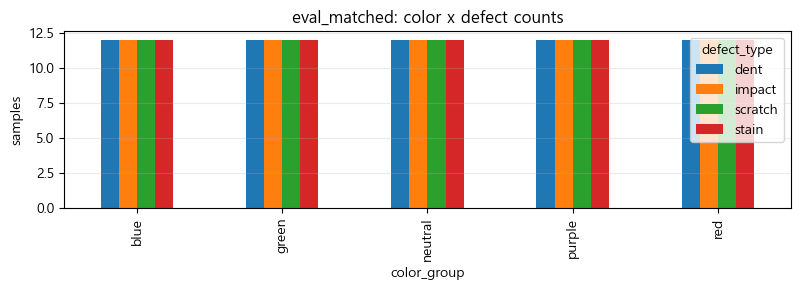

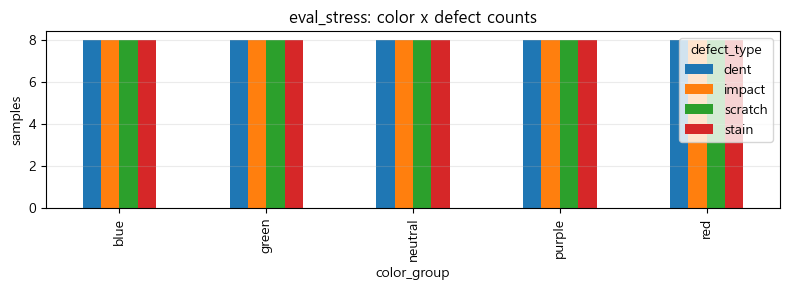

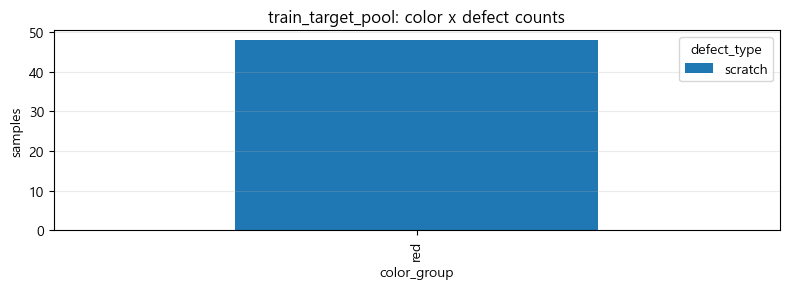

In [4]:
for split in ["train_matched", "eval_matched", "eval_stress", "train_target_pool"]:
    part = samples[samples["split"] == split]
    pivot = part.pivot_table(
        index="color_group",
        columns="defect_type",
        values="sample_id",
        aggfunc="count",
        fill_value=0,
    )
    ax = pivot.plot(kind="bar", figsize=(8, 3), title=f"{split}: color x defect counts")
    ax.set_ylabel("samples")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    out = paths.runs_root / "audit" / f"{split}_color_defect_counts.png"
    plt.savefig(out, dpi=150)
    plt.show()

## 23-3. 결론

In [5]:
print("결론: 데이터셋 audit가 통과했으므로 이제 SegFormer seed 반복 실험으로 넘어갈 수 있습니다.")
print("next notebook: 24_Chap2_2_Baseline_SegFormer_Seed_반복.ipynb")

결론: 데이터셋 audit가 통과했으므로 이제 SegFormer seed 반복 실험으로 넘어갈 수 있습니다.
next notebook: 24_Chap2_2_Baseline_SegFormer_Seed_반복.ipynb
